# Prosjekt 2: Analyse av politisk innflytelse

Prosjektet inneholder de følgende analysene:

1. Overfladisk statistisk analyse av datasettet. Hvor ofte samsvarer gruppenes mening med det som blir gjennomført? Hva med når de er uenige (hvem vinner)?
2. Koeffisienter for logistisk regresjon med kun en gruppe som treningsgrunnlag
3. Koeffisienter for logistisk regresjon når treningsgrunnlaget er uenighet mellom to grupper (rich minus poor)
4. Undersøkelse av feature importance vha. random forest modeller


# 0. Importering og behandling av datasett

In [856]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [857]:
df_DS1 = pd.read_stata("DS1_v2.dta")

In [858]:
all_cols = ['pred10_sw', 'pred30_sw', 'pred50_sw', 'pred70_sw', 'pred90_sw', 'PREDALL_SW']

In [859]:
clean_df = df_DS1.dropna(subset=['OUTCOME'] + all_cols, how='any')

In [860]:
df_DS1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1863 entries, 0 to 1862
Columns: 265 entries, ID8102 to _merge
dtypes: category(1), float64(262), str(2)
memory usage: 3.8 MB


In [861]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 1836 entries, 0 to 1862
Columns: 265 entries, ID8102 to _merge
dtypes: category(1), float64(262), str(2)
memory usage: 3.7 MB


In [862]:
print(clean_df.groupby('XL_AREA').size())

XL_AREA
budget           23
camp finance     64
civil rts        46
defense          63
econ & labor    110
education        63
environment      62
foreign pol     302
govt reform      39
guns             99
health          157
immigration      23
misc others     110
race             20
religious        94
soc welfare     136
taxation        284
terrorism        78
welf reform      63
dtype: int64


# 1. Overordnet analyse av datasett

In [863]:
lower_tresholds_fine  = np.linspace(0,0.9,10)
lower_tresholds_coarse = np.array([0, 0.3, 0.7])

In [864]:
def return_agreement_scores(df, category, group, lower_tresholds):
    if category != 'ALLCATS':
        sorted_cat = df[df['XL_AREA'] == category]
    else:
        sorted_cat = df
    
    agreement_scores = np.zeros_like(lower_tresholds, dtype=float)
    
    for i, treshold in enumerate(lower_tresholds):
        next_treshold = lower_tresholds[i+1] if i+1 < len(lower_tresholds) else 1.0
        df_in_treshold = sorted_cat[(sorted_cat[group] >= treshold) & (sorted_cat[group] <= next_treshold)]
        
        if len(df_in_treshold) > 0:
            score = (df_in_treshold['OUTCOME'] != 0).mean()
        else:
            score = np.nan  # Handle bins with no data points
            print(f"No data points for {group} in treshold range [{treshold}, {next_treshold}]")

        agreement_scores[i] = score

    return agreement_scores
    

In [865]:

def influence_graph(agreement_scores_list, category, groups, lower_tresholds):
    n_groups = len(groups)
    n_bins = len(lower_tresholds)

    x = np.arange(n_bins)

    gap = 0.07  # small extra gap before last group
    bar_width = (0.8 - gap) / n_groups

    plt.figure(figsize=(12, 6))

    for i, (scores, group_name) in enumerate(zip(agreement_scores_list, groups)):

        # Add extra spacing only before the last group
        if i == n_groups - 1:
            offset = i * bar_width + gap
        else:
            offset = i * bar_width

        plt.bar(
            x + offset,
            scores,
            width=bar_width,
            label=group_name
        )

    bin_labels = [
        f"[{lower_tresholds[i]:.1f}, {lower_tresholds[i+1]:.1f}]"
        if i + 1 < n_bins else f"[{lower_tresholds[i]:.1f}, 1.0]"
        for i in range(n_bins)
    ]

    # Center ticks under the full bar cluster
    total_width = n_groups * bar_width + gap
    plt.xticks(
        x + total_width / 2 - bar_width / 2,
        bin_labels,
        rotation=45,
        ha='right'
    )

    plt.ylim(0, 1)
    plt.xlabel("Agreement interval")
    plt.ylabel("Andel vedtatt (agreement score)")
    plt.title(f"Agreement score per group ({category})")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [866]:
def create_influence_graph(df, category, groups, lower_tresholds):
    agreement_scores_list = [return_agreement_scores(df, category, group, lower_tresholds) for group in groups]
    influence_graph(agreement_scores_list, category, groups, lower_tresholds)

### Alle saker

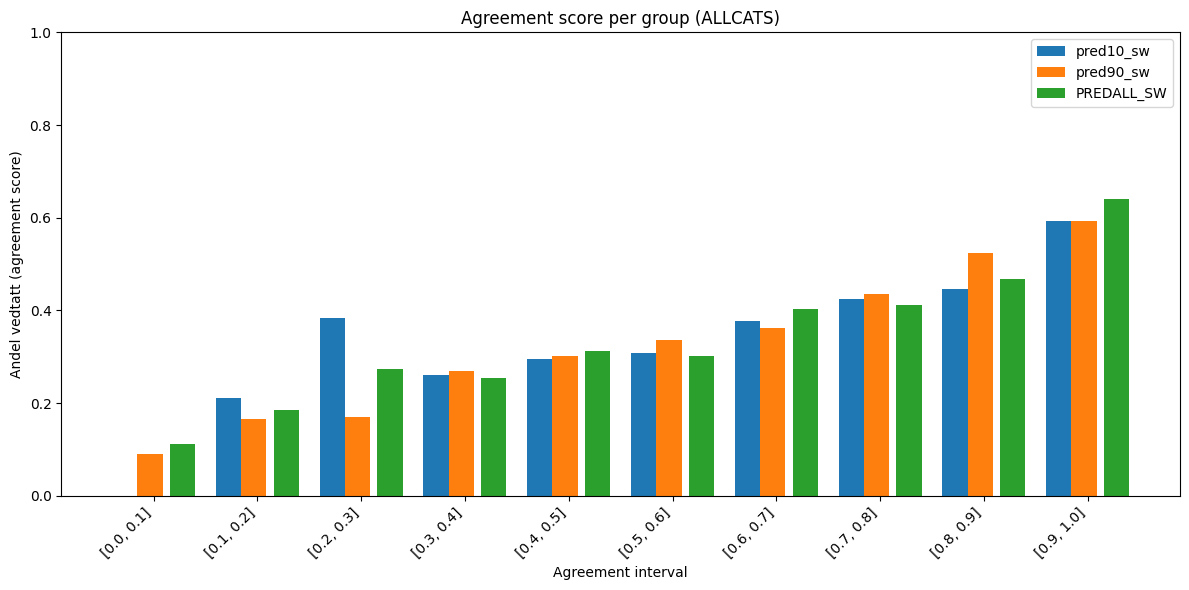

In [867]:
groups_extreme = ['pred10_sw', 'pred90_sw', 'PREDALL_SW']
lower_tresholds = [0.0, 0.25, 0.5, 0.75, 1.0]
create_influence_graph(clean_df, 'ALLCATS', groups_extreme, lower_tresholds_fine)


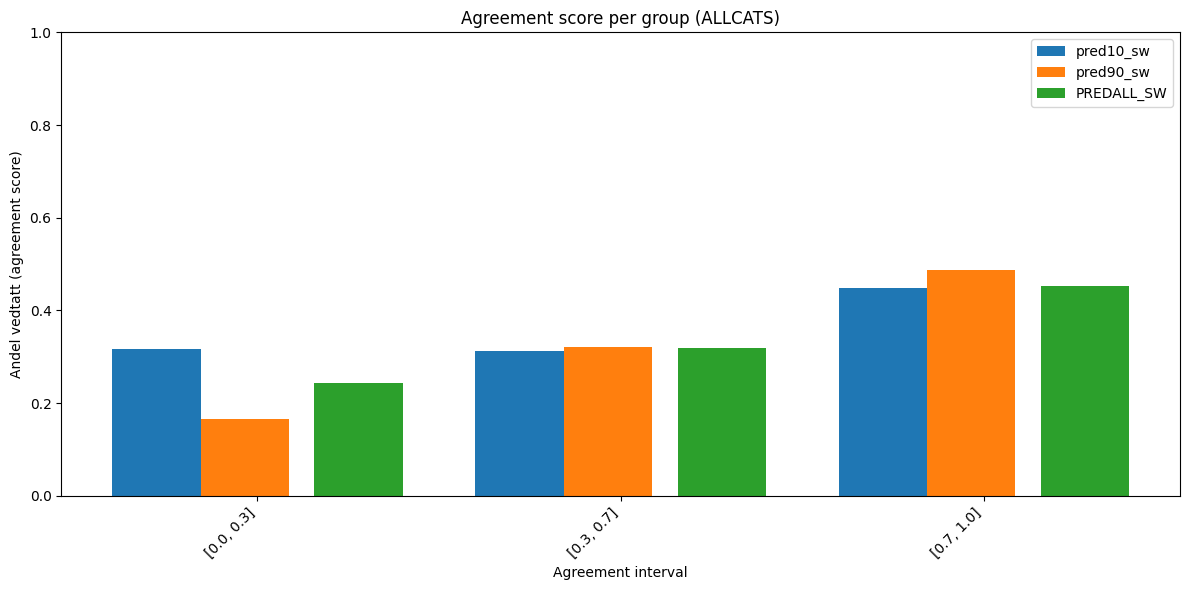

In [868]:
create_influence_graph(clean_df, 'ALLCATS', groups_extreme, lower_tresholds_coarse)

### Kun de sakene der det er uenighet mellom rike og fattige

In [869]:
conflict_df = clean_df[abs(clean_df['pred90_sw'] - clean_df['pred10_sw']) >= 0.15]
conflict_df.info()

<class 'pandas.DataFrame'>
Index: 378 entries, 0 to 1862
Columns: 265 entries, ID8102 to _merge
dtypes: category(1), float64(262), str(2)
memory usage: 783.0 KB


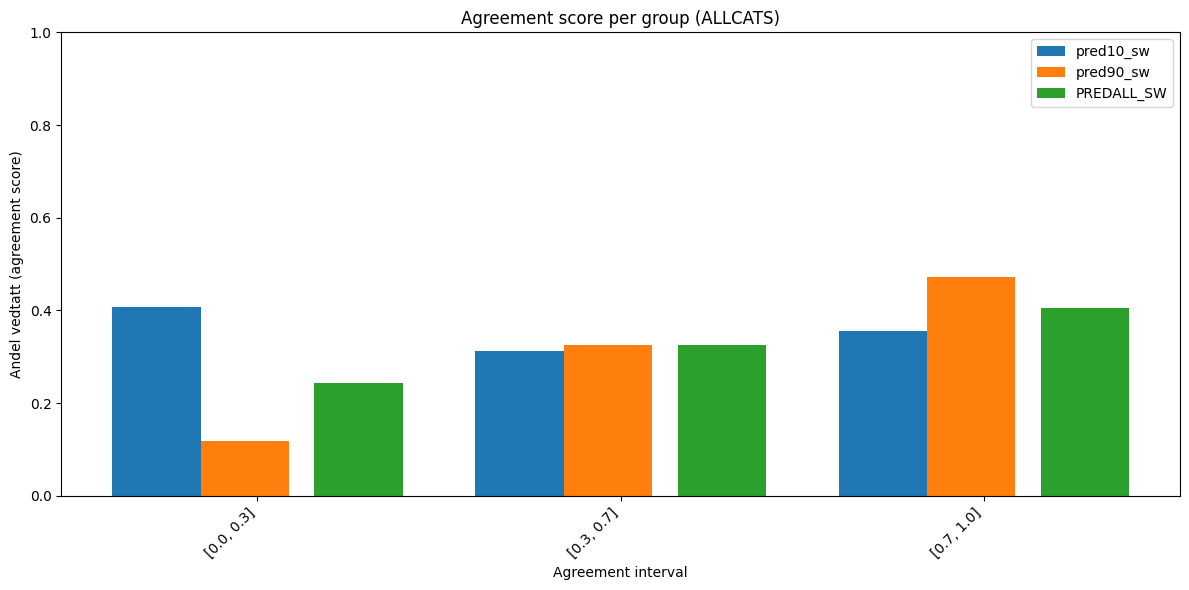

In [870]:
create_influence_graph(conflict_df, 'ALLCATS', groups_extreme, lower_tresholds_coarse)

# 2. Logistisk regresjon

In [871]:
def return_logistic_coefficients(df, groups):
    coeffs_by_group = {group: {} for group in groups}
    categories = sorted(df['XL_AREA'].unique())

    for category_name in categories:
        cat_df = df[df['XL_AREA'] == category_name]

        for group in groups:
            model_df = cat_df[[group, 'OUTCOME']]

            if model_df.empty:
                coeffs_by_group[group][category_name] = np.nan
                continue

            y = (model_df['OUTCOME'] != 0).astype(int)
            if y.nunique() < 2:
                coeffs_by_group[group][category_name] = np.nan
                continue

            X = model_df[[group]]
            model = LogisticRegression(max_iter=1000, C=np.inf)
            model.fit(X, y)

            coeffs_by_group[group][category_name] = float(model.coef_[0][0])

    return coeffs_by_group

In [872]:
def plot_logistic_coefficients(coef_df, groups):
    plt.figure(figsize=(12, 6))
    sns.heatmap(coef_df[groups], annot=True, cmap='coolwarm', center=0)
    plt.title("Logistic Regression Coefficients by Group and Policy Category")
    plt.xlabel("Groups")
    plt.ylabel("Policy category")
    plt.tight_layout()
    plt.show()

In [873]:
groups_all = ['pred10_sw', 'pred30_sw', 'pred50_sw', 'pred70_sw', 'pred90_sw', 'PREDALL_SW']

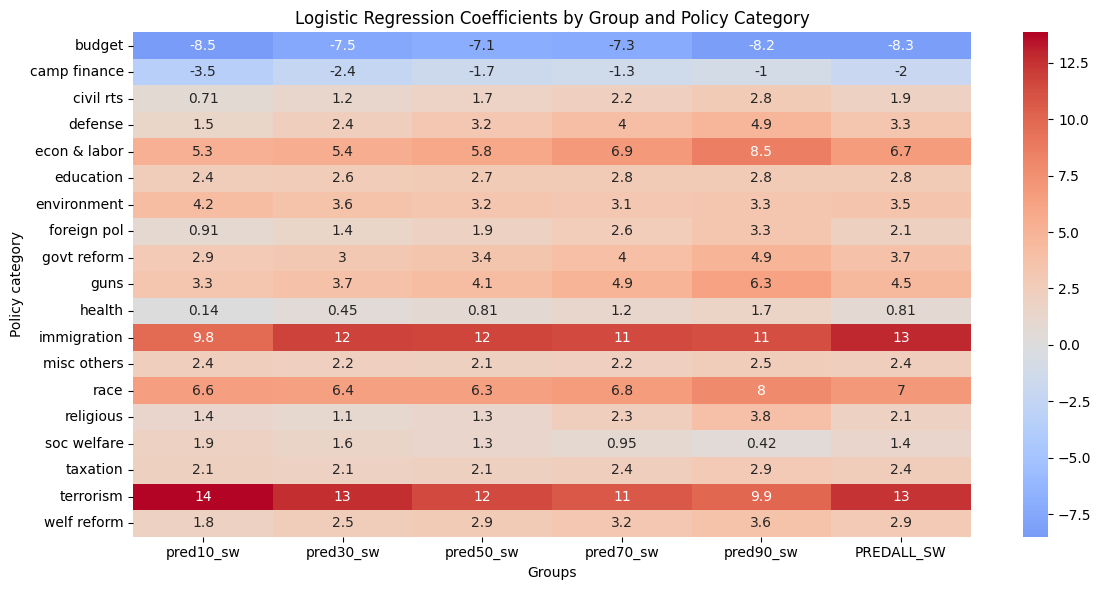

In [874]:
coefs_by_group = return_logistic_coefficients(clean_df, groups_all)
plot_logistic_coefficients(pd.DataFrame(coefs_by_group), groups_all)

# 3. Logistisk regresjon til å sammenligne grupper

In [875]:
def return_logistic_coefficients_comparison(df, group1, group2):
    coeffs_comparison = {}
    categories = sorted(df['XL_AREA'].dropna().unique())

    for category_name in categories:
        cat_df = df[df['XL_AREA'] == category_name][[group1, group2, 'OUTCOME']].dropna()

        if cat_df.empty:
            coeffs_comparison[category_name] = np.nan
            continue

        X = (cat_df[group1] - cat_df[group2]).to_frame(name='opinion_diff')
        y = (cat_df['OUTCOME'] != 0).astype(int)

        if y.nunique() < 2:
            coeffs_comparison[category_name] = np.nan
            continue

        model = LogisticRegression(max_iter=1000, C=np.inf)
        model.fit(X, y)

        coeffs_comparison[category_name] = float(model.coef_[0][0])

    return coeffs_comparison

In [876]:
def plot_comparison_coefficients(coef_comparison, group1, group2):
    coef_df = pd.DataFrame.from_dict(coef_comparison, orient='index', columns=['Coefficient'])
    plt.figure(figsize=(12, 6))
    sns.barplot(x=coef_df.index, y='Coefficient', data=coef_df, palette='coolwarm', hue='Coefficient', legend=False)
    plt.title(f"Logistic Regression Coefficients for {group1} vs {group2}")
    plt.xlabel("Policy category")
    plt.ylabel("Coefficient (opinion difference)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

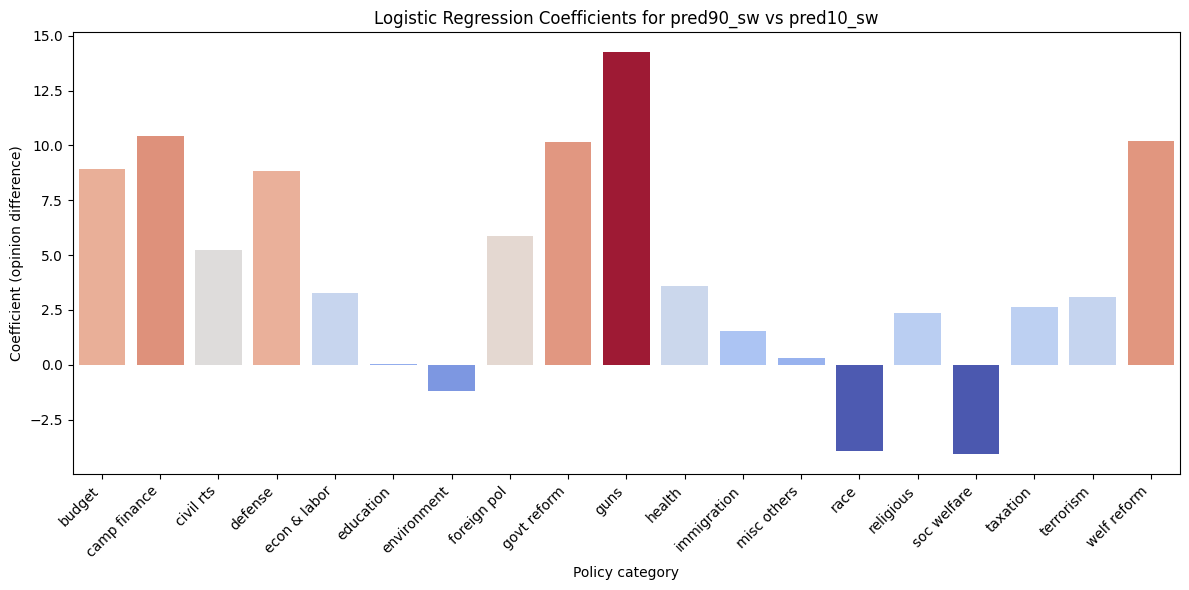

In [877]:
coeficients = return_logistic_coefficients_comparison(clean_df, groups_extreme[1], groups_extreme[0])
plot_comparison_coefficients(coeficients, groups_extreme[1], groups_extreme[0])

# 4. Random forest analyse

In [878]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [879]:
X = clean_df[groups_all]
Y = (clean_df['OUTCOME'] != 0).astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

skog = RandomForestClassifier(n_estimators=100, max_features="sqrt", random_state=42)
skog.fit(X_train, Y_train)
print(f"Ferdigtrent skog med {skog.n_estimators} trær, max_features={skog.max_features}")

Ferdigtrent skog med 100 trær, max_features=sqrt


In [880]:
print(X.columns)

Index(['pred10_sw', 'pred30_sw', 'pred50_sw', 'pred70_sw', 'pred90_sw',
       'PREDALL_SW'],
      dtype='str')


In [881]:
Y_pred = skog.predict(X_test)
score = accuracy_score(Y_test, Y_pred)
print(f'Random forest score på test-data: {score}')

Random forest score på test-data: 0.6195652173913043


<BarContainer object of 6 artists>

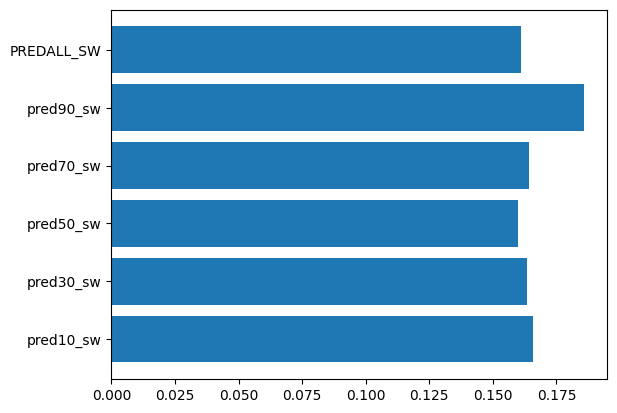

In [882]:
importance = skog.feature_importances_
plt.barh(X_train.columns, importance)

### Shapley values

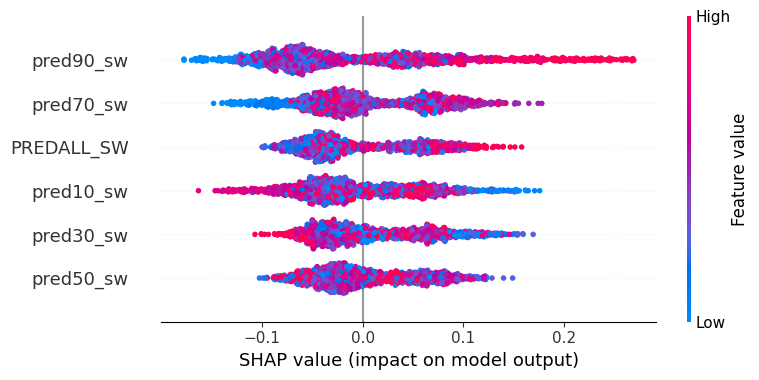

In [883]:
import shap

explainer = shap.TreeExplainer(skog)
shap_values = explainer.shap_values(X_train)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

shap.summary_plot(shap_values_class1, X_train)

In [884]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay

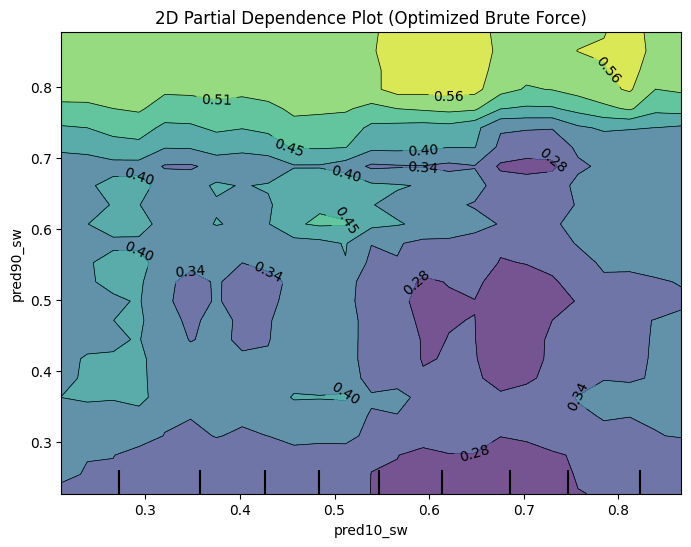

In [885]:
features = [('pred10_sw', 'pred90_sw')]

fig, ax = plt.subplots(figsize=(8, 6))

# Fixed by switching to method='brute' and defining response_method
PartialDependenceDisplay.from_estimator(
    skog, 
    X, 
    features, 
    ax=ax,
    method='brute',                 # Required for this classifier setup
    response_method='predict_proba', # Tells it to look at probability of passing (0 to 1)
    grid_resolution=25               # Keeps the grid tiny (25x25) so brute force is fast!
)

plt.title("2D Partial Dependence Plot (Optimized Brute Force)")
plt.show()

### Beslutningstre

In [886]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [887]:
tre = DecisionTreeClassifier(max_depth=3, random_state=42)
tre.fit(X_train, Y_train)
print(f"Nøyaktighet: {accuracy_score(Y_test, tre.predict(X_test))*100:.1f}%")

Nøyaktighet: 66.8%


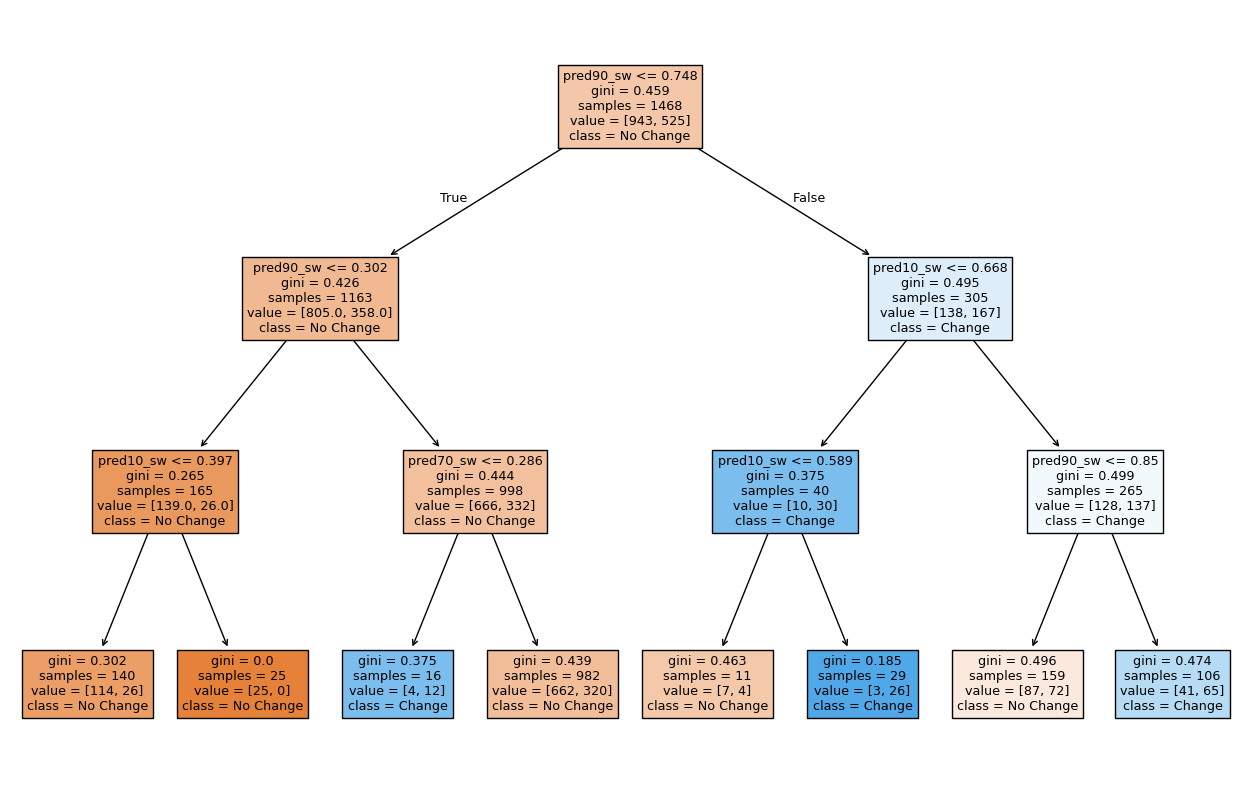

In [888]:
plt.figure(figsize=(16,10))
plot_tree(tre, max_depth=3, feature_names=X_train.columns, class_names=["No Change", "Change"], filled=True)
plt.show()